In [1]:
!pip install sklearn scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [6]:
import pandas as pd

# Read Reddit Data
reddit_comments = pd.read_csv("reddit_comments.csv")
yt_comments = pd.read_excel("method-1-youtube/scripts/youtube_comments.xlsx", sheet_name="youtube_base")
comments = pd.concat([reddit_comments, comments])
comments

,url,text,title,link,date_published,like_count,reply_parent_id
0,https://www.reddit.com/r/newsPH/comments/1luqe...,"Misleading title. ""Most Pinoys disagree with i...",NaN,NaN,NaN,NaN,NaN
1,https://www.reddit.com/r/newsPH/comments/1luqe...,I disagree. More Pinoys want accountability.,NaN,NaN,NaN,NaN,NaN
2,https://www.reddit.com/r/newsPH/comments/1luqe...,SWS = Sara Walang Silbi\n\nHow fitting.,NaN,NaN,NaN,NaN,NaN
3,https://www.reddit.com/r/newsPH/comments/1luqe...,credible pa ba ang sws survey ngayon?,NaN,NaN,NaN,NaN,NaN
4,https://www.reddit.com/r/newsPH/comments/1luqe...,Iba-iba result ng survey depende sa nag commis...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
3038,NaN,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T03:33:27Z,5.0,NaN
3039,NaN,Salute Sen.Marcoleta,Salute Sen.Marcoleta,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T05:58:03Z,2.0,NaN
3040,NaN,"Senator Marcoleta, my two thumbs up for you. Y...","Senator Marcoleta, my two thumbs up for you. Y...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-06T17:43:46Z,9.0,NaN
3041,NaN,"Yes now, l know why the imp. Was the un contit...","Yes now, l know why the imp. Was the un contit...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-08T01:17:36Z,1.0,NaN


count    3100.000000
mean       92.594516
std       109.268127
min         1.000000
25%        34.000000
50%        65.000000
75%       113.250000
max      2197.000000
Name: text, dtype: float64
count    3043.000000
mean       20.887282
std       141.176139
min         0.000000
25%         0.000000
50%         1.000000
75%         8.000000
max      5360.000000
Name: like_count, dtype: float64
text
Tama                                                                                               10
❤❤❤                                                                                                 5
🤔                                                                                                   4
​@@JuanManuel-t9kBugok kaya nagkaroon ng West Philippines Sea sa google dahil kay marcoleta 🥰😘😍     4
💚💚💚                                                                                                 4
😂😂😂😂😂                                                                                    

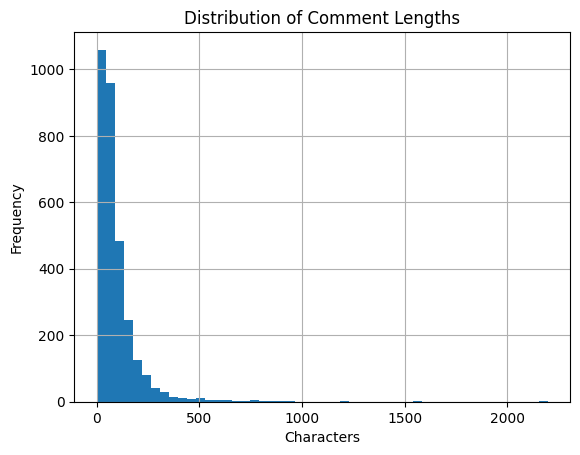

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['batas', 'taong', 'si', 'wala', 'ba', 'bayan', 'di', 'lang', 'nga', 'mo']
---
Topic 1:
['duterte', 'hahaha', 'yung', 'lang', 'impeachment', 'kasi', 'mo', 'po', 'si', 'yan']
---
Topic 2:
['like', 'bless', 'senator', 'senators', 'people', 'god', 'good', 'senate', 'po', 'sen']
---
Topic 3:
['senador', 'po', 'kayo', 'senado', 'sen', 'senator', 'mo', 'si', 'yan', 'marcoleta']
---
Topic 4:
['batas', 'philhealth', 'mo', 'si', 'di', 'nyo', 'naman', 'sen', 'yung', 'lang']
---


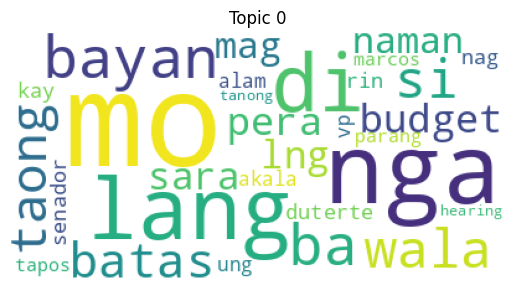

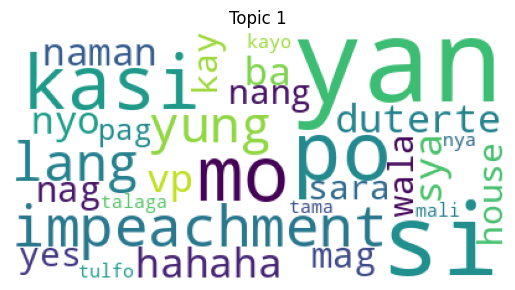

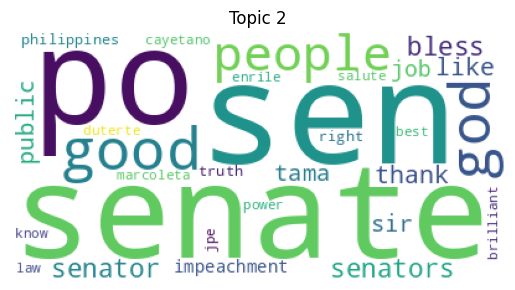

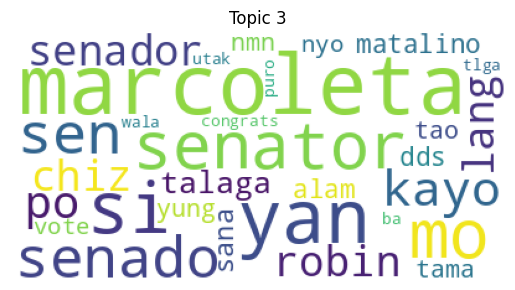

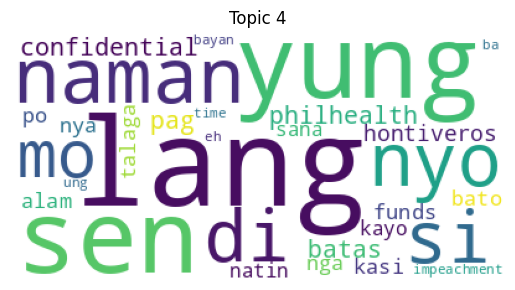

In [28]:
# Load Data
import pandas as pd

# Exploratory Data Analysis
# basic stats
print(comments['text'].str.len().describe())
print(yt_comments['like_count'].describe())

# Most common comments
print(comments['text'].value_counts().head(10))

# distribution of comment lengths
import matplotlib.pyplot as plt
comments['text'].str.len().hist(bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# nlp Preprocessing
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

tagalog_stop_words = ["akin","aking","ako","alin","am","amin","aming","ang","ano","anumang","apat","at","atin","ating","ay","bababa","bago","bakit","bawat","bilang","dahil","dalawa","dapat","din","dito","doon","gagawin","gayunman","ginagawa","ginawa","ginawang","gumawa","gusto","habang","hanggang","hindi","huwag","iba","ibaba","ibabaw","ibig","ikaw","ilagay","ilalim","ilan","inyong","isa","isang","itaas","ito","iyo","iyon","iyong","ka","kahit","kailangan","kailanman","kami","kanila","kanilang","kanino","kanya","kanyang","kapag","kapwa","karamihan","katiyakan","katulad","kaya","kaysa","ko","kong","kulang","kumuha","kung","laban","lahat","lamang","likod","lima","maaari","maaaring","maging","mahusay","makita","marami","marapat","masyado","may","mayroon","mga","minsan","mismo","mula","muli","na","nabanggit","naging","nagkaroon","nais","nakita","namin","napaka","narito","nasaan","ng","ngayon","ni","nila","nilang","nito","niya","niyang","noon","o","pa","paano","pababa","paggawa","pagitan","pagkakaroon","pagkatapos","palabas","pamamagitan","panahon","pangalawa","para","paraan","pareho","pataas","pero","pumunta","pumupunta","sa","saan","sabi","sabihin","sarili","sila","sino","siya","tatlo","tayo","tulad","tungkol","una","walang"]
stop_words = set(stopwords.words('english')) | set(tagalog_stop_words)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

comments['processed_text'] = comments['text'].apply(clean_text)
comments[['text','processed_text']].head()

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(comments['processed_text'])

# fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# print top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])
    print("---")

# visualize topics with word clouds
from wordcloud import WordCloud

for idx, topic in enumerate(lda.components_):
    plt.figure()
    plt.imshow(WordCloud(background_color='white').fit_words({terms[i]: topic[i] for i in topic.argsort()[-30:]}))
    plt.axis("off")
    plt.title(f"Topic {idx}")
    plt.savefig(f"topic{idx}.png")

# Assign Topics to Comments
comment_topics = lda.transform(X).argmax(axis=1)
comments['topic'] = comment_topics
comments[['text','topic']].head(20)

# Save results
comments.to_excel("comments_with_topics.xlsx", index=False)

## Exploratory data Analysis
- Number of comments: 3043
- distribution of lengths is skewed (most under 200 characters)
- Most common words include political names (Risa (hontiveros), Raffy (tulfo), etc.)

## Topic Modeling Results
- Topic 0: Support for Risa Hontiveros
- Topic 1: Criticism & comparisons with other senators
- Topic 2: Conversational fillers in tagalog
- Topic 3: political commentary in general
- Topic 4: Mentions of senators (Chiz, Marcoleta, etc.)


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import numpy as np

In [11]:
len(lda.components_)

5

In [12]:
lda.components_

array([[0.20000375, 0.20099248, 6.20047707, ..., 0.22831481, 0.20041417,
        0.20001561],
       [2.19864794, 1.19888939, 0.20597401, ..., 0.2005513 , 0.20001112,
        0.20222217],
       [0.20062179, 0.20000469, 0.20225406, ..., 0.20000852, 0.2007019 ,
        0.20160648],
       [0.20000452, 0.20000596, 1.19077213, ..., 4.17111692, 6.19779304,
        0.20499722],
       [0.200722  , 1.20010748, 0.20052273, ..., 0.20000845, 0.20107977,
        4.19115851]])

In [13]:
lda.components_[0].argsort()[-15:]

array([1662, 2259, 1310, 1945,  305,  202, 2523, 2337, 2717,  149,  212,
        530, 1256, 1735, 1573])

In [9]:
comments

,title,link,date_published,text,like_count,reply_parent_id,processed_text,topic
0,I really admire Sen. Risa&#39;s calm and wise ...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-24T15:48:54Z,I really admire Sen. Risa's calm and wise appr...,406,NaN,really admire sen risas calm wise approach que...,0
1,Very pro not so palengkera like Legarda 😂,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-27T16:29:28Z,Very pro not so palengkera like Legarda 😂,2,UgwdNtAh7g0iT4uV8k94AaABAg,pro palengkera like legarda,1
2,Sen Hontiveros proves she deserves her spot in...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T07:16:34Z,Sen Hontiveros proves she deserves her spot in...,5360,NaN,sen hontiveros proves deserves spot senate,1
3,how about sen raffy?,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T09:51:42Z,how about sen raffy?,78,Ugz3t5SAfz3h9CzEE7x4AaABAg,sen raffy,1
4,PROUD AKO BINOTO KO YAN SI HONTIVEROS!!! di ak...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T09:58:40Z,PROUD AKO BINOTO KO YAN SI HONTIVEROS!!! di ak...,227,Ugz3t5SAfz3h9CzEE7x4AaABAg,proud ako binoto ko yan si hontiveros di ako n...,4
...,...,...,...,...,...,...,...,...
3038,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T03:33:27Z,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,5,NaN,di ba hindi man si sen marcolleta sa eat bulag...,4
3039,Salute Sen.Marcoleta,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T05:58:03Z,Salute Sen.Marcoleta,2,NaN,salute senmarcoleta,4
3040,"Senator Marcoleta, my two thumbs up for you. Y...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-06T17:43:46Z,"Senator Marcoleta, my two thumbs up for you. Y...",9,NaN,senator marcoleta two thumbs smartest senator ...,1
3041,"Yes now, l know why the imp. Was the un contit...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-08T01:17:36Z,"Yes now, l know why the imp. Was the un contit...",1,NaN,yes l know imp un contitutional complain one,0


In [14]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix=vectorizer.fit_transform(comments['processed_text'])

In [15]:
topic_term_matrix = lda.components_
doc_topic_matrix = lda.transform(doc_term_matrix)

In [16]:
vocab = vectorizer.get_feature_names_out()
doc_lengths = [len(doc) for doc in comments['processed_text']]
term_freqs = doc_term_matrix.sum(axis=0)
term_freqs = np.array(term_freqs).flatten()
vis_data = pyLDAvis.prepare(topic_term_matrix, doc_topic_matrix, doc_lengths, vocab, term_freqs)

pyLDAvis.display(vis_data)

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download(["vader_lexicon"])

senti = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [19]:
def sentiment_analysis(dataframe, textcolumn):
    for index, row in dataframe.iterrows():
        senti_score = senti.polarity_scores(str(row[textcolumn]))
        dataframe.loc[index, 'neg'] = senti_score['neg']
        dataframe.loc[index, 'neu'] = senti_score['neu']
        dataframe.loc[index, 'pos'] = senti_score['pos']
        dataframe.loc[index, 'compound'] = senti_score['compound']
    return dataframe

In [20]:
comment_sentiments = sentiment_analysis(comments, textcolumn='processed_text')

In [21]:
comment_sentiments[['text', 'neg', 'neu', 'pos', 'compound']]

,text,neg,neu,pos,compound
0,"Misleading title. ""Most Pinoys disagree with i...",0.077,0.383,0.541,0.8173
1,I disagree. More Pinoys want accountability.,0.000,0.545,0.455,0.3612
2,SWS = Sara Walang Silbi\n\nHow fitting.,0.000,1.000,0.000,0.0000
3,credible pa ba ang sws survey ngayon?,0.000,1.000,0.000,0.0000
4,Iba-iba result ng survey depende sa nag commis...,0.000,0.659,0.341,0.4767
...,...,...,...,...,...
3038,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,0.000,0.472,0.528,0.9231
3039,Salute Sen.Marcoleta,0.000,1.000,0.000,0.0000
3040,"Senator Marcoleta, my two thumbs up for you. Y...",0.000,0.715,0.285,0.8677
3041,"Yes now, l know why the imp. Was the un contit...",0.245,0.490,0.265,0.0516


In [22]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/julyanna/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
def affect_analysis(dataframe, textcolumn):
    for ix, row in dataframe.iterrows():
        text = str(row[textcolumn])
        text_obj = NRCLex(text)
        affect_dict = text_object.affect_frequencies
        for key, val in affect_dict.items():
            dataframe.loc[ix, key] = val
    return dataframe

In [26]:
comment_affects = affect_analysis(comments, "processed_text")
comment_affects

,url,text,title,link,date_published,like_count,reply_parent_id,processed_text,topic,neg,...,fear,anger,anticip,trust,surprise,positive,negative,sadness,disgust,joy
0,https://www.reddit.com/r/newsPH/comments/1luqe...,"Misleading title. ""Most Pinoys disagree with i...",NaN,NaN,NaN,NaN,NaN,misleading title pinoys disagree impeachment c...,1,0.077,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
1,https://www.reddit.com/r/newsPH/comments/1luqe...,I disagree. More Pinoys want accountability.,NaN,NaN,NaN,NaN,NaN,disagree pinoys want accountability,1,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
2,https://www.reddit.com/r/newsPH/comments/1luqe...,SWS = Sara Walang Silbi\n\nHow fitting.,NaN,NaN,NaN,NaN,NaN,sws sara silbi fitting,0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
3,https://www.reddit.com/r/newsPH/comments/1luqe...,credible pa ba ang sws survey ngayon?,NaN,NaN,NaN,NaN,NaN,credible ba sws survey,0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
4,https://www.reddit.com/r/newsPH/comments/1luqe...,Iba-iba result ng survey depende sa nag commis...,NaN,NaN,NaN,NaN,NaN,ibaiba result survey depende nag commission su...,1,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3038,NaN,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T03:33:27Z,5.0,NaN,di ba man si sen marcolleta eat bulaga napataw...,2,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
3039,NaN,Salute Sen.Marcoleta,Salute Sen.Marcoleta,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T05:58:03Z,2.0,NaN,salute senmarcoleta,3,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
3040,NaN,"Senator Marcoleta, my two thumbs up for you. Y...","Senator Marcoleta, my two thumbs up for you. Y...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-06T17:43:46Z,9.0,NaN,senator marcoleta two thumbs smartest senator ...,2,0.000,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4
3041,NaN,"Yes now, l know why the imp. Was the un contit...","Yes now, l know why the imp. Was the un contit...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-08T01:17:36Z,1.0,NaN,yes l know imp un contitutional complain one,2,0.245,...,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.4


In [30]:
comment_affects[['text', 'neu', 'positive', 'neg', 'compound', 'negative', 'disgust', 'surprise', 'joy', 'sadness', 'anger', 'fear', 'surprise', 'anticip']].describe()

,neu,positive,neg,compound,negative,disgust,surprise,joy,sadness,anger,fear,surprise,anticip
count,3100.000000,3.100000e+03,3100.000000,3100.000000,3100.0,3100.0,3100.0,3100.0,3100.0,3100.0,3100.0,3100.0,3100.0
mean,0.810407,6.000000e-01,0.056573,0.067184,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
std,0.267699,1.110402e-16,0.137706,0.346076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,6.000000e-01,0.000000,-0.980800,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
25%,0.654750,6.000000e-01,0.000000,0.000000,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
50%,1.000000,6.000000e-01,0.000000,0.000000,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
75%,1.000000,6.000000e-01,0.000000,0.128000,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
max,1.000000,6.000000e-01,1.000000,0.985300,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0
